In [152]:
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
df = pd.read_csv('telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

TotalCharges column showing str type which means this column has some string but it should be float. Thus we have to find such tuples in this feature and have to make them nan so that we can replace those tuples with relatable numerical values.

In [155]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan).astype(float)

Here, we have replace " " (space) with nan values, and have changed the datatype to float

In [156]:
print(df.isnull().sum().sort_values(ascending=False)[:5])

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
dtype: int64


Now, we can see the null values in TotalCharges attribute.

In [157]:
# Fill missing values in 'TotalCharges' with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [158]:
df.isnull().sum().sort_values(ascending=False)[:5]

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
dtype: int64

Now we can see that there is no missing values in TotalCharges attribute.

In [159]:
# seeing statistics of the data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [160]:
# dropping the customerID column as it is not useful for our analysis
df.drop('customerID', axis = 1, inplace = True)

In [161]:
# separating numerical and categorical columns
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


C:\Users\j\AppData\Local\Temp\ipykernel_3908\2564215874.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [162]:
# checking for duplicates
df.duplicated().sum()

np.int64(22)

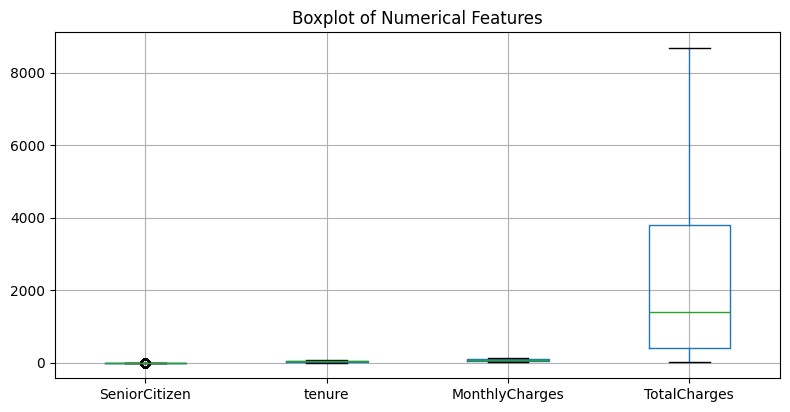

In [163]:
# visualizing the distribution of numerical features using boxplots to identify outliers.
df[num_cols].boxplot(figsize=(8,4))
plt.tight_layout()
plt.title("Boxplot of Numerical Features")
plt.show()

# Exploratory Data Analysis

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

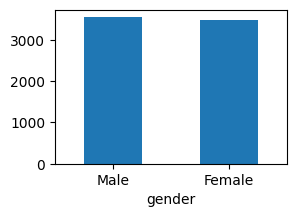

In [165]:
# visualizing the distribution of feature "gender" using a bar plot to see the count of each category.
df["gender"].value_counts().plot(kind = "bar", figsize = (3,2))
plt.xticks(rotation = 0)
plt.show()

Both genders use the telecom service eqaully which shows that society is empowerd especially women. 

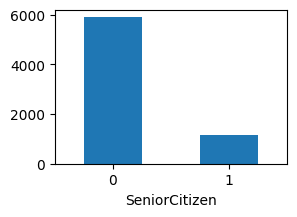

In [166]:
# visualizing the distribution of feature "SeniorCitizen" using a bar plot to see the count of each category.
df["SeniorCitizen"].value_counts().plot(kind = "bar", figsize = (3,2))
plt.xticks(rotation = 0)
plt.show()

This plot shows that most of the users are younger.

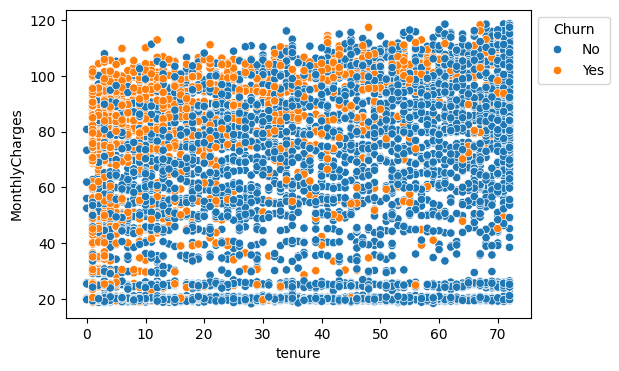

In [167]:
# visualizing the relationship between "tenure" and "MonthlyCharges" using a scatter plot, colored by "Churn" to see 
# if there are any patterns.        
plt.figure(figsize = (6,4) )
sns.scatterplot(data = df, x = 'tenure', y = 'MonthlyCharges', hue = 'Churn')
plt.legend( bbox_to_anchor = (1,1 ), title = "Churn")

plt.show()

The scatter plot clearly indicates that monthly charges are almost similar in all tenure, but churn rate is higher in those who are new to service. Churn rate reduces as the tenure of service usage increases which means longer the customer uses the service lesser the chances of churn.

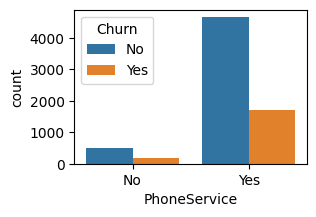

In [168]:
# visualizing the distribution of feature "PhoneService" using a bar plot to see the count of each category.
plt.figure(figsize = (3,2) )
sns.countplot(data = df, x = 'PhoneService', hue = 'Churn' )

plt.xticks(rotation = 0)
plt.show()

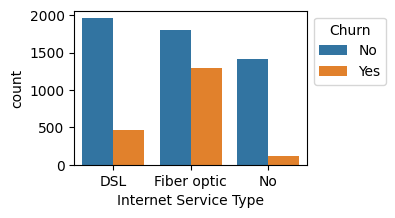

In [169]:
# visualizing the distribution of feature "InternetService" using a  countplot with hue to see the churn rates 
# for each category.
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'InternetService', hue = "Churn")
plt.xticks(rotation = 0)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Internet Service Type" )
plt.show()

Customers who are using Fiber optic internet service are highly prone to churn, while who are not using any internet service are very less prone to churn.

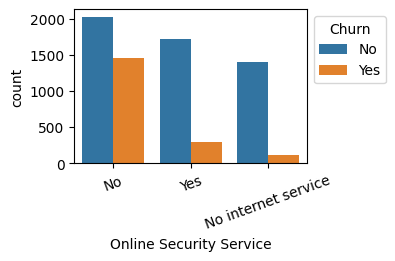

In [170]:
# visualizing the distribution of feature "OnlineSecurity" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'OnlineSecurity', hue = "Churn")
plt.xticks(rotation = 20)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Online Security Service" )
plt.show()

Here, we can clearly see that customers who have no Online Security Service churn the most whereas those who have online security service churn less. Customers, who have no internet connection churn the least. 

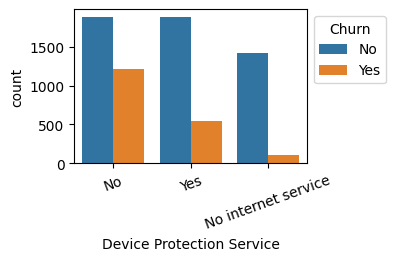

In [171]:
# visualizing the distribution of feature "DeviceProtection" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'DeviceProtection', hue = "Churn")
plt.xticks(rotation = 20)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Device Protection Service")
plt.show()

Here also, we can observe that customers with no device protection service are more prone to churn than those who have device protection service. Whereas customers, who have no internet service, are the least prone to quit the service and join other comminication service.

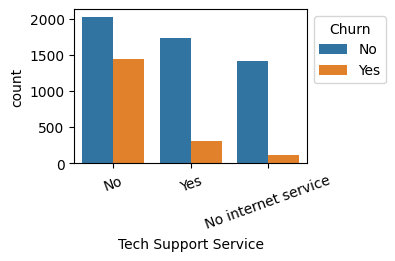

In [172]:
# visualizing the distribution of feature "TechSupport" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'TechSupport', hue = "Churn")
plt.xticks(rotation = 20)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Tech Support Service")
plt.show()

Same churning pattern can be detected here also.
1. no tech support = higher churn rate
2. tech support = less churn 
3. no internet connection = very low churning.

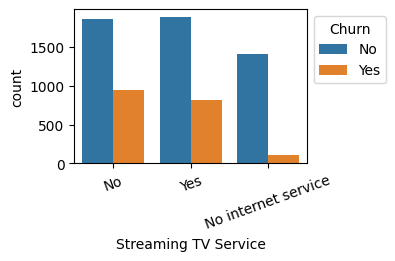

In [173]:
# visualizing the distribution of feature "TechSupport" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'StreamingTV', hue = "Churn")
plt.xticks(rotation = 20)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Streaming TV Service")
plt.show()

Having Streaming TV service does not affect the churning rate very significantly. However, customers who are not using taking internet are still loyal to the telco.

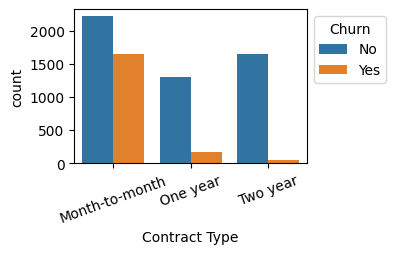

In [174]:
# visualizing the distribution of feature "Contract" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'Contract', hue = "Churn")
plt.xticks(rotation = 20)
plt.legend( bbox_to_anchor = (1,1), title = "Churn")
plt.xlabel("Contract Type")
plt.show()

Around 50% customers do monthly contract, and around 40% among them churn. It shows that majority of the customers uses short tenure contract so that they can switch to other company's services, and can utelise their money in best optimised way.

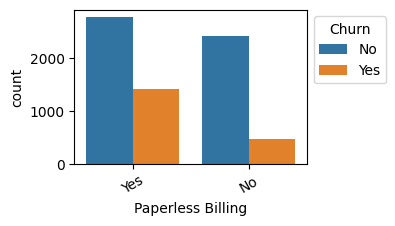

In [175]:
# visualizing the distribution of feature "PaperlessBilling" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'PaperlessBilling', hue = 'Churn')
plt.xticks(rotation = 30)
plt.legend( bbox_to_anchor = (1,1), title = 'Churn')
plt.xlabel("Paperless Billing")
plt.show()

The plot shows that those who still pay bill with paper may not have access to internet or may be uncomfortable in using internet. There are possibilities that bill payer, who are using paper, are senior citizens. On the other side, those who are paying bills paperless may be younger and tech aware and can compare service cost of different companies and switch to the best suitable company service.

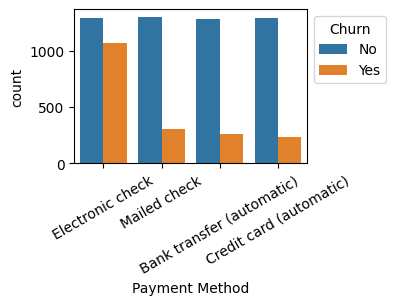

In [176]:
# visualizing the distribution of feature "PaymentMethod" using a  countplot with hue to see the churn rates
plt.figure(figsize = (3,2))
sns.countplot(data = df, x = 'PaymentMethod', hue = 'Churn')
plt.xticks(rotation = 30)
plt.legend(bbox_to_anchor = (1,1), title = 'Churn')
plt.xlabel("Payment Method")
plt.show()

Churning rate is significantly high in case of Electronic check. There can be many causes behind it which are given as.
1. Those using electronic check may switch easily to another company's service.
2. May be, paying through Electronic check causes delay in payment. 
3. may be, payment interface is not easy to operate.

All of these things may cause this churn in electronic check payment method.

# Feature Engineering: Feature Selection and Encoding

In [177]:
# Separating input features and target feature.
x = df.drop('Churn', axis = 1)
y = df["Churn"]

In [178]:
# Dropping the target variable from the list of categorical columns so that it can be used for encoding.
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != 'Churn']

C:\Users\j\AppData\Local\Temp\ipykernel_3908\2916832041.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != 'Churn']


In [179]:
# Splitting the data into training and testing sets with a test size of 20% and a random state for reproducibility.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [180]:
# Encoding categorical features using OneHotEncoder, which converts categorical variables into a format that can be provided to Neural Network to do a 
# better job in prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)


In [181]:
# Encoding train_y, test_y using simple map function.
y_train_encoded = y_train.map({'No': 0, 'Yes': 1})
y_test_encoded = y_test.map({'No': 0, 'Yes': 1})

In [182]:
x_train_encoded.shape, y_train_encoded.shape, x_test_encoded.shape, y_test_encoded.shape

((5634, 45), (5634,), (1409, 45), (1409,))

In [183]:
# Using Sequential Feature Selector to select the top 10 features that are most relevant for predicting customer churn.
model = LogisticRegression(max_iter=1000)
sfs = SequentialFeatureSelector(model, n_features_to_select=10)
sfs.fit(x_train_encoded, y_train_encoded)



,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",10
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mi

In [184]:
# similarly we will extract top 10 features for the test set to ensure that the model is trained and tested on the same features.
mask = sfs.get_support()
x_train_selected_10 = x_train_encoded[:, mask]
x_test_selected_10 = x_test_encoded[:, mask]
print(x_train_selected_10.shape    )
print(x_test_selected_10.shape)



(5634, 10)
(1409, 10)


In [185]:
# list of top 10 selected features.
feature_names = preprocessor.get_feature_names_out()
selected_features = np.array(feature_names)[sfs.get_support()]

selected_features.tolist()


['cat__PhoneService_No',
 'cat__PhoneService_Yes',
 'cat__MultipleLines_No phone service',
 'cat__StreamingMovies_No',
 'cat__StreamingMovies_Yes',
 'cat__Contract_Two year',
 'num__SeniorCitizen',
 'num__tenure',
 'num__MonthlyCharges',
 'num__TotalCharges']

In [186]:
# extracting top 20 features using sequential feature selector dimentionality reduction technique.
model = LogisticRegression(max_iter=10000)
sfs = SequentialFeatureSelector(model, n_features_to_select=20)
sfs.fit(x_train_encoded, y_train_encoded)




,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...ax_iter=10000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",20
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mi

In [187]:
mask = sfs.get_support()
x_train_selected_20 = x_train_encoded[:, mask]
x_test_selected_20 = x_test_encoded[:, mask]
print(x_train_selected_20.shape)
print(x_test_selected_20.shape)

(5634, 20)
(1409, 20)


In [188]:
feature_names = preprocessor.get_feature_names_out()
selected_features = np.array(feature_names)[sfs.get_support()]
selected_features.tolist()

['cat__gender_Female',
 'cat__Partner_No',
 'cat__Partner_Yes',
 'cat__PhoneService_No',
 'cat__PhoneService_Yes',
 'cat__MultipleLines_No phone service',
 'cat__InternetService_No',
 'cat__OnlineSecurity_No internet service',
 'cat__OnlineBackup_No internet service',
 'cat__DeviceProtection_No internet service',
 'cat__TechSupport_No internet service',
 'cat__StreamingTV_No internet service',
 'cat__StreamingMovies_No',
 'cat__StreamingMovies_No internet service',
 'cat__StreamingMovies_Yes',
 'cat__Contract_Two year',
 'num__SeniorCitizen',
 'num__tenure',
 'num__MonthlyCharges',
 'num__TotalCharges']

# Training Neural Network

### Training neural network with top 20 features

In [201]:
# converting the selected features and the target features into tensors using pytorch to train the model.
x_train_tensor_20 = torch.from_numpy(x_train_selected_20).float()
x_test_tensor_20 = torch.from_numpy(x_test_selected_20).float()

y_train_tensor = torch.from_numpy(y_train_encoded.to_numpy()).float().view(-1, 1)
y_test_tensor = torch.from_numpy(y_test_encoded.to_numpy()).float().view(-1, 1)

In [202]:
# creating a class for feedforward NN with 2 hidden layers using ReLu activation fucntion and an output layer with sigmoid
# activation fucntion.
class ChurnNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

model = ChurnNN(x_train_tensor_20.shape[1])

In [203]:
# defining binary cross entropy loss function and adam optimizer for training the model.
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [204]:
# Training the model for 500 epochs and printing the loss every 100 epochs to monitor the training process.
epochs = 500

for epoch in range(epochs):
    
    outputs = model(x_train_tensor_20)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.7758294343948364
Epoch 100, Loss: 0.5341832637786865
Epoch 200, Loss: 0.4471820890903473
Epoch 300, Loss: 0.43742796778678894
Epoch 400, Loss: 0.43311193585395813


In [205]:
# Evaluating the model on the test set and printing the classification report to see the performance of the model.
with torch.no_grad():
    preds = model(x_test_tensor_20)
    preds = (preds > 0.5).float()

print(classification_report(y_test_tensor, preds))

              precision    recall  f1-score   support

         0.0       0.83      0.92      0.87      1036
         1.0       0.69      0.47      0.56       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [207]:

# checking overfitting and underfitting by calculating the accuracy on both train and test set.
predicted = (outputs > 0.5).float()
train_acc = (predicted == y_train_tensor).sum().item() / len(y_train_tensor)

val_predicted = (preds > 0.5).float()
val_acc = (val_predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print("training_accuracy:", train_acc)
print("validation_accuracy:", val_acc)

training_accuracy: 0.7928647497337593
validation_accuracy: 0.8041163946061036


Model is not overfitting as both model accuracy on train and test data giving almost same results

### Training Neural Network using top 10 features

In [208]:
# converting the selected features and the target features into tensors using pytorch to train the model.
x_train_tensor_10 = torch.from_numpy(x_train_selected_10).float()
x_test_tensor_10 = torch.from_numpy(x_test_selected_10).float()

In [209]:
x_train_tensor_10.shape

torch.Size([5634, 10])

In [210]:
# making a class of 2 hidden layers each with ReLu activation function and an output layer with sigmoid activation fucntion.
class ChurnNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 10),
            nn.ReLU(),
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Linear(5, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

model = ChurnNN(x_train_tensor_10.shape[1])

In [211]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [212]:
epochs = 500

for epoch in range(epochs):
    
    outputs = model(x_train_tensor_10)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.6742322444915771
Epoch 100, Loss: 0.5566720962524414
Epoch 200, Loss: 0.4624762237071991
Epoch 300, Loss: 0.44535303115844727
Epoch 400, Loss: 0.4406197965145111


In [213]:
# avaluating the result through confusion matrix.
with torch.no_grad():
    preds = model(x_test_tensor_10)
    preds = (preds > 0.5).float()

print(classification_report(y_test_tensor, preds))

              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87      1036
         1.0       0.67      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [214]:
# checking overfitting and underfitting by calculating the accuracy on both train and test set.
predicted = (outputs > 0.5).float()
train_acc = (predicted == y_train_tensor).sum().item() / len(y_train_tensor)

val_predicted = (preds > 0.5).float()
val_acc = (val_predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print("training_accuracy:", train_acc)
print("validation_accuracy:", val_acc)

training_accuracy: 0.7930422435214768
validation_accuracy: 0.8048261178140526
